In [2]:
!pip install pandas numpy scikit-learn matplotlib seaborn tqdm requests

  You can safely remove it manually.
  You can safely remove it manually.


In [7]:
import os, re, time, math, random, unicodedata, shutil
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, matthews_corrcoef,
                             roc_auc_score, roc_curve, classification_report)

# ----------------------------- CONFIG -----------------------------
SEED            = 42
DATA_PATH       = "Dataset.csv"                           # put Dataset.csv next to this notebook
OUT_DIR         = "./llm_eval_outputs_lmstudio"

LMSTUDIO_BASE   = "http://localhost:1234/v1"
MODEL_NAME      = "qwen3-4b-instruct-2507"                               # <-- set exactly after running Cell 3
THINKING_MODEL  = False                                    # True if the model emits <think>...</think>

SHOTS_PER_CLASS = [0, 3]                                   # zero-shot and 3-shot (k examples PER CLASS)
MAX_TEST_CHARS  = 1200
MAX_SHOT_CHARS  = 380
CLASS_NAMES     = {0: "NoMHD", 1: "MHD"}

MAX_NEW_TOKENS  = 900 if THINKING_MODEL else 6
REQUEST_TIMEOUT = 180
MAX_RETRIES     = 4

VERBOSE_ROWS = True
PRINT_EVERY  = 1             # use 5-10 for the full run
TEXT_PREVIEW = 70
SAVE_EVERY   = 25            # checkpoint to disk every N rows
# ------------------------------------------------------------------

os.makedirs(OUT_DIR, exist_ok=True)
random.seed(SEED); np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.3)
PAL = sns.color_palette("colorblind")
PAL

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [8]:
resp = requests.get(f"{LMSTUDIO_BASE}/models", timeout=10)
resp.raise_for_status()
ids = [m["id"] for m in resp.json()["data"]]
print("Models LM Studio currently has LOADED:")
for m in ids:
    print(" -", m)

if not ids:
    raise RuntimeError("No models loaded. In LM Studio: load a model, then Developer tab -> start the server.")
if MODEL_NAME not in ids:
    print(f"\n⚠ MODEL_NAME = {MODEL_NAME!r} does not exactly match a loaded model. "
          f"Copy the exact id above into Cell 2 and re-run this cell.")
else:
    print(f"\n✔ MODEL_NAME = {MODEL_NAME!r} matches a loaded model.")

Models LM Studio currently has LOADED:
 - qwen3-4b-instruct-2507
 - phi-4-mini-instruct
 - llama-3.2-3b-instruct
 - text-embedding-nomic-embed-text-v1.5

✔ MODEL_NAME = 'qwen3-4b-instruct-2507' matches a loaded model.


In [9]:
def clean(s):
    return " ".join(unicodedata.normalize("NFC", str(s)).split())   # normalise Bangla Unicode variants

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Can't find {DATA_PATH}. Put Dataset.csv next to this notebook, "
                            f"or set DATA_PATH to the full path.")

df = pd.read_csv(DATA_PATH, header=None, names=["text", "label"])   # no header row in the file
df = df.dropna(subset=["text", "label"]).copy()
df["text"]  = df["text"].apply(clean)
df["label"] = df["label"].astype(int)
df = df[df["text"].str.len() > 0].drop_duplicates(subset="text").reset_index(drop=True)
df["n_chars"] = df["text"].str.len()

print("Usable samples:", len(df))
print(df["label"].map(CLASS_NAMES).value_counts())

Usable samples: 7109
label
MHD      3598
NoMHD    3511
Name: count, dtype: int64


In [10]:
POS_DEMOS = df[df.label == 1].sample(max(SHOTS_PER_CLASS), random_state=SEED).text.tolist()
NEG_DEMOS = df[df.label == 0].sample(max(SHOTS_PER_CLASS), random_state=SEED).text.tolist()

def clip(t, n=MAX_SHOT_CHARS):
    return t if len(t) <= n else t[:n].rsplit(" ", 1)[0] + " ..."

def get_shots(k):
    shots = []
    for i in range(k):
        pair = [(clip(POS_DEMOS[i]), 1), (clip(NEG_DEMOS[i]), 0)]
        if i % 2 == 1: pair = pair[::-1]
        shots.extend(pair)
    return shots

SHOTS = {k: get_shots(k) for k in SHOTS_PER_CLASS}

demo_texts = set(POS_DEMOS) | set(NEG_DEMOS)
test_df = df[~df.text.isin(demo_texts)].reset_index(drop=True)

# For a quick TRIAL run first (local inference can be slow, especially CPU-only), uncomment:
# test_df = test_df.sample(150, random_state=SEED).reset_index(drop=True)

print("Demo examples (label 1 / MHD):")
for t in POS_DEMOS: print(" -", t[:100])
print("\nDemo examples (label 0 / NoMHD):")
for t in NEG_DEMOS: print(" -", t[:100])

print(f"\nEvaluation set: {len(test_df)} rows (demos excluded: {len(demo_texts)})")
print(test_df["label"].map(CLASS_NAMES).value_counts())

pd.DataFrame([(i + 1, "MHD", clip(t)) for i, t in enumerate(POS_DEMOS)] +
             [(i + 1, "NoMHD", clip(t)) for i, t in enumerate(NEG_DEMOS)],
             columns=["order", "class", "text"]).to_csv(f"{OUT_DIR}/fewshot_examples_used.csv", index=False)

Demo examples (label 1 / MHD):
 - আমি একজন ছেলে, বয়স ২৬। আমার ঘটনা টা যদি কারো কাছে হাস্যকর মনে হয় প্লিজ ইগ্নর করবেন। আসলে আমি একটা 
 - আমি একজন মেয়ে।আমি একটা ইঞ্জিনিয়ারিং সাবজেক্টে পড়াশোনা করছি।এখানে ল্যাব ওয়ার্কে গ্রুপ করে বিভিন্ন
 - আসসালামুআলাইকুম। আমি একজন মেয়ে।মানসিক শান্তির জন্য আপনাদের সাথে লাইফের একটা ঘটনা শেয়ার করতে চাই। ২

Demo examples (label 0 / NoMHD):
 - আদরে, যত্নে আমার আপু যেনো আমার মায়ের ছায়া।
 - খোলা আকাশের নিচে সবাই মিলে পিকনিক, টক মিষ্টি আচার।
 - বঙ্গবন্ধু কে আমরা সবাই ভালোবাসি কিন্তু এরা কি শুরু করেছে 😮🥴 আমি শিহরিত #sharifahmedkhan

Evaluation set: 7103 rows (demos excluded: 6)
label
MHD      3595
NoMHD    3508
Name: count, dtype: int64


In [11]:
SYSTEM_PROMPT = """তুমি একজন অভিজ্ঞ ক্লিনিক্যাল সাইকোলজিস্ট। তোমার কাজ বাংলা সোশ্যাল মিডিয়া লেখা পড়ে ঠিক করা: লেখক নিজের মানসিক স্বাস্থ্য সংক্রান্ত কোনো কষ্ট বা সমস্যার কথা জানাচ্ছেন কি না।

লেবেল 1 (MHD): নিচের যেকোনো একটি সত্য হলে।
ক) লেখক নিজের (বা নিজের খুব কাছের কারও) মানসিক বা আবেগীয় কষ্ট, উপসর্গ বা আচরণগত সমস্যা বর্ণনা করছেন। যেমন: ঘুম না হওয়া, অতিরিক্ত দুশ্চিন্তা বা ভয়, একই চিন্তা বারবার আসা, রাগ বা মেজাজ নিয়ন্ত্রণ করতে না পারা, একাকিত্ব, হতাশা, অকারণ কান্না, মনোযোগ নষ্ট হওয়া, বেঁচে থাকার ইচ্ছা কমে যাওয়া। রোগের নাম না থাকলেও চলবে।
খ) লেখক এমন সমস্যা থেকে মুক্তির উপায়, চিকিৎসা, পরামর্শ বা সাহায্য চাইছেন (যেমন "কী করবো?", "সমাধান আছে কি?")।
গ) পরিবার, সম্পর্ক, পড়াশোনা বা আসক্তি (যেমন মোবাইল আসক্তি) নিয়ে নিজের অসহায়তা ও মানসিক চাপ প্রকাশ করছেন।
ঘ) লেখাটি মানসিক রোগ, ট্রমা বা উপসর্গ কী তা ব্যাখ্যা করছে।

লেবেল 0 (NoMHD): লেখক নিজের কোনো মানসিক সমস্যা বা সাহায্যের প্রয়োজন প্রকাশ করছেন না। যেমন:
- ভালোবাসার ঘোষণা, কবিতা, গানের কলি, উক্তি, ক্যাপশন
- গল্প, উপন্যাস বা ধারাবাহিকের অংশ (চরিত্রের নাম, সংলাপ, "পর্ব"), এমনকি চরিত্র কাঁদলে বা কষ্ট পেলেও
- অন্যকে দেওয়া উপদেশ, অনুপ্রেরণামূলক বা ধর্মীয় কথা, ঠাট্টা বা মজা
- কৃতজ্ঞতা বা আনন্দের প্রকাশ, দৈনন্দিন সুখের অভিজ্ঞতা, ছবি, ভ্রমণ বা খেলা নিয়ে মন্তব্য
- খবর, বিজ্ঞাপন, সাধারণ তথ্য বা সাধারণ প্রশ্ন

সতর্কতা:
1. শুধু শব্দ দেখে সিদ্ধান্ত নেবে না। "মৃত্যু", "কষ্ট", "কান্না", "সুইসাইড", "ডিপ্রেশন" শব্দ কবিতা, গল্প, উপদেশ বা ঠাট্টায় থাকলে উত্তর 0। আবার এসব শব্দ না থাকলেও নিজের ঘুমের সমস্যা, দুশ্চিন্তা, রাগ বা অস্থিরতার বর্ণনা থাকলে উত্তর 1।
2. "আমি" দিয়ে লেখা হলেই 1 নয়। দেখো লেখক কি নিজের চলমান কষ্ট জানাচ্ছেন বা সাহায্য চাইছেন, নাকি আনন্দ প্রকাশ করছেন, গল্প বলছেন বা কাউকে ভালোবাসার কথা জানাচ্ছেন।
3. লেখা এক-দুই বাক্যের ছোট হলেও নিজের উপসর্গ বা কষ্টের বর্ণনা থাকলে 1।
4. লেখা লম্বা হওয়া বা গল্পের ভঙ্গিতে লেখা হওয়া নিজে কোনো প্রমাণ নয়। লেখক বাস্তবে নিজের সমস্যার কথা বলছেন কি না, সেটাই বিচার্য।

উত্তরে শুধু একটি অঙ্ক লিখবে: 1 অথবা 0। আর কিছু লিখবে না।"""

USER_TEMPLATE = ('লেখা:\n"""{text}"""\n\n'
                 'প্রশ্ন: লেখক কি নিজের মানসিক কষ্ট বা সমস্যার কথা জানাচ্ছেন, সাহায্য চাইছেন, '
                 'অথবা এ বিষয়ে ব্যাখ্যা করছেন? (1 = হ্যাঁ, 0 = না)\nউত্তর:')

def build_messages(text, shots):
    msgs = [{"role": "system", "content": SYSTEM_PROMPT}]
    for s_text, s_label in shots:
        msgs.append({"role": "user", "content": USER_TEMPLATE.format(text=s_text)})
        msgs.append({"role": "assistant", "content": str(s_label)})
    msgs.append({"role": "user", "content": USER_TEMPLATE.format(text=text[:MAX_TEST_CHARS])})
    return msgs

with open(f"{OUT_DIR}/prompt.txt", "w", encoding="utf-8") as f:
    f.write("SYSTEM PROMPT:\n" + SYSTEM_PROMPT + "\n\nUSER TEMPLATE:\n" + USER_TEMPLATE + "\n")

In [12]:
DIGIT_RE = re.compile(r"[01]")
session = requests.Session()

def call_lmstudio(messages, max_tokens):
    payload = {
        "model": MODEL_NAME, "messages": messages, "temperature": 0.0,
        "max_tokens": max_tokens, "seed": SEED,
        "logprobs": True, "top_logprobs": 20,   # usually honoured (llama.cpp backend), not officially guaranteed
    }
    last_err = None
    for attempt in range(MAX_RETRIES):
        try:
            r = session.post(f"{LMSTUDIO_BASE}/chat/completions", json=payload, timeout=REQUEST_TIMEOUT)
            r.raise_for_status()
            return r.json()
        except Exception as e:
            last_err = e
            time.sleep(1.5 * (attempt + 1))
    raise RuntimeError(f"LM Studio request failed after {MAX_RETRIES} attempts: {last_err}")

def parse_response(data):
    """Returns (p_mhd, valid). Finds the LAST '0'/'1' the model produced (handles thinking
    models too). Uses logprobs for a real probability when returned; else a hard 0/1."""
    choice = data["choices"][0]
    content = choice.get("message", {}).get("content") or ""
    visible = re.sub(r"<think>.*?</think>", "", content, flags=re.S)
    search_in = visible if DIGIT_RE.search(visible) else content
    matches = list(DIGIT_RE.finditer(search_in))
    if not matches:
        return 0.5, False

    label = int(matches[-1].group())
    p1 = float(label)

    lp_content = (choice.get("logprobs") or {}).get("content")
    if lp_content:
        for entry in reversed(lp_content):
            if DIGIT_RE.search(entry.get("token", "")):
                cands = {c["token"].strip(): c["logprob"] for c in entry.get("top_logprobs", [])}
                lp0, lp1v = cands.get("0"), cands.get("1")
                if lp0 is not None and lp1v is not None:
                    e0, e1 = math.exp(lp0), math.exp(lp1v)
                    p1 = e1 / (e0 + e1)
                elif lp1v is not None:
                    p1 = math.exp(lp1v)
                elif lp0 is not None:
                    p1 = 1 - math.exp(lp0)
                break
    return p1, True

def score_one(text, shots):
    data = call_lmstudio(build_messages(text, shots), MAX_NEW_TOKENS)
    return parse_response(data)

In [13]:
print(f"Server: {LMSTUDIO_BASE} | Model: {MODEL_NAME} | thinking model: {THINKING_MODEL}\n")
for k in SHOTS_PER_CLASS:
    name = "Zero-shot" if k == 0 else f"{k}-shot"
    print(f"=== {name} ===")
    for i in range(2):
        r = test_df.iloc[i]
        t0 = time.time()
        p1, valid = score_one(r.text, SHOTS[k])
        print(f"  row {i} | true={CLASS_NAMES[int(r.label)]:<5} P(MHD)={p1:.3f} valid={valid} "
              f"| {time.time()-t0:.1f}s | {r.text[:70]}")

Server: http://localhost:1234/v1 | Model: qwen3-4b-instruct-2507 | thinking model: False

=== Zero-shot ===
  row 0 | true=NoMHD P(MHD)=0.000 valid=True | 3.4s | আজ বললো, মা আমরা মুসলিম একবার আসছি পৃথিবীতে আর আসবো না মৃত্যুর পর। এই 
  row 1 | true=MHD   P(MHD)=1.000 valid=True | 0.2s | আমি আপনার থেকে আরো বেশিদিন এই নরক যন্তনা ভোগ করছি।সারাক্ষন ভয়ে ভয়ে থ
=== 3-shot ===
  row 0 | true=NoMHD P(MHD)=0.000 valid=True | 1.3s | আজ বললো, মা আমরা মুসলিম একবার আসছি পৃথিবীতে আর আসবো না মৃত্যুর পর। এই 
  row 1 | true=MHD   P(MHD)=1.000 valid=True | 0.3s | আমি আপনার থেকে আরো বেশিদিন এই নরক যন্তনা ভোগ করছি।সারাক্ষন ভয়ে ভয়ে থ


In [14]:
def setting_name(k): return "Zero-shot" if k == 0 else f"{k}-shot"

def run_setting(k):
    name, shots = setting_name(k), SHOTS[k]
    final = f"{OUT_DIR}/preds_{name}.csv"
    part  = f"{OUT_DIR}/partial_{name}.npz"
    if os.path.exists(final):
        print(f"[loaded] {name}"); return pd.read_csv(final)

    texts = test_df.text.tolist(); ys = test_df.label.values; N = len(texts)

    if os.path.exists(part):
        z = np.load(part); p1, valid, done = z["p1"], z["valid"], int(z["done"])
        pr = (p1[:done] >= 0.5).astype(int)
        tp = int(((pr == 1) & (ys[:done] == 1)).sum()); fp = int(((pr == 1) & (ys[:done] == 0)).sum())
        fn = int(((pr == 0) & (ys[:done] == 1)).sum()); tn = int(((pr == 0) & (ys[:done] == 0)).sum())
        print(f"[resume] {name} from row {done}/{N}")
    else:
        p1, valid, done = np.zeros(N), np.zeros(N, dtype=bool), 0
        tp = fp = fn = tn = 0

    print("\n" + "=" * 110)
    print(f"  RUNNING: {name}   |   rows: {N}   |   demos in prompt: {len(shots)}")
    print("=" * 110)

    log = open(f"{OUT_DIR}/rowlog_{name}.txt", "a", encoding="utf-8")
    pbar = tqdm(total=N, initial=done, desc=name, unit="row", dynamic_ncols=True)
    t0, start = time.time(), done

    for i in range(done, N):
        pm, ok = score_one(texts[i], shots)
        y = int(ys[i]); pr = int(pm >= 0.5)
        p1[i], valid[i] = pm, ok
        tp += (pr == 1 and y == 1); fp += (pr == 1 and y == 0)
        fn += (pr == 0 and y == 1); tn += (pr == 0 and y == 0)
        acc = (tp + tn) / (i + 1)
        line = (f"{name:<9}| #{i:>5} | true={CLASS_NAMES[y]:<5} pred={CLASS_NAMES[pr]:<5} "
                f"P(MHD)={pm:.3f} {'✔' if pr == y else '✘'}{'' if ok else ' ⚠fmt'} "
                f"| run-acc={acc:.3f} | {texts[i][:TEXT_PREVIEW]}")
        log.write(line + "\n")
        if VERBOSE_ROWS and i % PRINT_EVERY == 0:
            tqdm.write(line)
        pbar.update(1)
        pbar.set_postfix(acc=f"{(tp+tn)/(i+1):.3f}", TP=tp, FP=fp, FN=fn, TN=tn,
                         fmt=f"{valid[:i+1].mean():.2f}", rows_s=f"{(i+1-start)/(time.time()-t0):.2f}")
        if (i + 1) % SAVE_EVERY == 0 or i == N - 1:
            np.savez(part, p1=p1, valid=valid, done=i + 1); log.flush()

    pbar.close(); log.close()

    out = test_df[["text", "label", "n_chars"]].copy()
    out["p_mhd"] = p1; out["pred"] = (p1 >= 0.5).astype(int); out["valid_format"] = valid
    out.to_csv(final, index=False); os.remove(part)

    prec1, rec1 = tp / max(tp + fp, 1), tp / max(tp + fn, 1)
    prec0, rec0 = tn / max(tn + fn, 1), tn / max(tn + fp, 1)
    print(f"\n>>> {name} finished in {(time.time()-t0)/60:.1f} min")
    print(f"    Overall accuracy = {(tp+tn)/N:.4f}")
    print(f"    NoMHD (0): precision = {prec0:.4f} | recall = {rec0:.4f}")
    print(f"    MHD   (1): precision = {prec1:.4f} | recall = {rec1:.4f}")
    print(f"    Confusion: TN={tn}  FP={fp}  FN={fn}  TP={tp}\n")
    return out

preds = {}
for k in SHOTS_PER_CLASS:
    preds[setting_name(k)] = run_setting(k)


  RUNNING: Zero-shot   |   rows: 7103   |   demos in prompt: 0


Zero-shot:   0%|          | 0/7103 [00:00<?, ?row/s]

Zero-shot| #    0 | true=NoMHD pred=NoMHD P(MHD)=0.002 ✔ | run-acc=1.000 | আজ বললো, মা আমরা মুসলিম একবার আসছি পৃথিবীতে আর আসবো না মৃত্যুর পর। এই 
Zero-shot| #    1 | true=MHD   pred=MHD   P(MHD)=1.000 ✔ | run-acc=1.000 | আমি আপনার থেকে আরো বেশিদিন এই নরক যন্তনা ভোগ করছি।সারাক্ষন ভয়ে ভয়ে থ
Zero-shot| #    2 | true=NoMHD pred=MHD   P(MHD)=0.935 ✘ | run-acc=0.667 | _ এই যে ম্যাডাম, কয়টায় আসার কথা ছিল? _ আরে সরি সরি , এভাবে রাগ করিস 
Zero-shot| #    3 | true=NoMHD pred=NoMHD P(MHD)=0.000 ✔ | run-acc=0.750 | _ প্রতিটা মেয়ে তার বাবার কাছে রাজকন্যা- _ অনেক ভালোবাসি বাবা তোমায়..
Zero-shot| #    4 | true=NoMHD pred=NoMHD P(MHD)=0.000 ✔ | run-acc=0.800 | _ ভালোবাসি সবসময় শুধু তোমাকে'ই ভালোবাসি!'💝🌸
Zero-shot| #    5 | true=NoMHD pred=MHD   P(MHD)=0.987 ✘ | run-acc=0.667 | _ সংসারের দায়িত্ব যখন মায়ের হাতে_ _ অনেক ভালোবাসি মা....!😭🖤
Zero-shot| #    6 | true=NoMHD pred=MHD   P(MHD)=0.999 ✘ | run-acc=0.571 | __ আচ্ছা সুজয় তোমাকে কিছুদিন ধরে একটা কথা বলব ভাবছিলাম... __ হ্যাঁ, ব
Zero-shot| # 

3-shot:   0%|          | 0/7103 [00:00<?, ?row/s]

3-shot   | #    0 | true=NoMHD pred=NoMHD P(MHD)=0.000 ✔ | run-acc=1.000 | আজ বললো, মা আমরা মুসলিম একবার আসছি পৃথিবীতে আর আসবো না মৃত্যুর পর। এই 
3-shot   | #    1 | true=MHD   pred=MHD   P(MHD)=1.000 ✔ | run-acc=1.000 | আমি আপনার থেকে আরো বেশিদিন এই নরক যন্তনা ভোগ করছি।সারাক্ষন ভয়ে ভয়ে থ
3-shot   | #    2 | true=NoMHD pred=MHD   P(MHD)=1.000 ✘ | run-acc=0.667 | _ এই যে ম্যাডাম, কয়টায় আসার কথা ছিল? _ আরে সরি সরি , এভাবে রাগ করিস 
3-shot   | #    3 | true=NoMHD pred=NoMHD P(MHD)=0.000 ✔ | run-acc=0.750 | _ প্রতিটা মেয়ে তার বাবার কাছে রাজকন্যা- _ অনেক ভালোবাসি বাবা তোমায়..
3-shot   | #    4 | true=NoMHD pred=NoMHD P(MHD)=0.000 ✔ | run-acc=0.800 | _ ভালোবাসি সবসময় শুধু তোমাকে'ই ভালোবাসি!'💝🌸
3-shot   | #    5 | true=NoMHD pred=MHD   P(MHD)=0.994 ✘ | run-acc=0.667 | _ সংসারের দায়িত্ব যখন মায়ের হাতে_ _ অনেক ভালোবাসি মা....!😭🖤
3-shot   | #    6 | true=NoMHD pred=MHD   P(MHD)=1.000 ✘ | run-acc=0.571 | __ আচ্ছা সুজয় তোমাকে কিছুদিন ধরে একটা কথা বলব ভাবছিলাম... __ হ্যাঁ, ব
3-shot   | # 

In [19]:
rows = []
for name, d in preds.items():
    y, yp, p = d.label.values, d.pred.values, d.p_mhd.values
    P, R, F, S = precision_recall_fscore_support(y, yp, labels=[0, 1], zero_division=0)
    _, _, Fm, _ = precision_recall_fscore_support(y, yp, average="macro", zero_division=0)
    rows.append({
        "Setting": name,
        "Overall Accuracy": accuracy_score(y, yp),
        "Precision (NoMHD)": P[0], "Recall (NoMHD)": R[0], "F1 (NoMHD)": F[0],
        "Precision (MHD)":   P[1], "Recall (MHD)":   R[1], "F1 (MHD)":   F[1],
        "Macro-F1": Fm, "MCC": matthews_corrcoef(y, yp), "ROC-AUC": roc_auc_score(y, p),
        "Format adherence": d.valid_format.mean(), "N": len(d),
    })

metrics = pd.DataFrame(rows).set_index("Setting")
metrics.round(4).to_csv(f"{OUT_DIR}/metrics_summary.csv")
metrics.round(4).to_latex(f"{OUT_DIR}/metrics_summary.tex", float_format="%.4f")
pd.set_option("display.width", 250)
print(metrics.round(4))

for name, d in preds.items():
    print(f"\n===== {name} — full classification report =====")
    print(classification_report(d.label, d.pred, target_names=["NoMHD (0)", "MHD (1)"], digits=4))

           Overall Accuracy  Precision (NoMHD)  Recall (NoMHD)  F1 (NoMHD)  Precision (MHD)  Recall (MHD)  F1 (MHD)  Macro-F1     MCC  ROC-AUC  Format adherence     N
Setting                                                                                                                                                               
Zero-shot            0.9147             0.9603          0.8629      0.9090           0.8783        0.9652    0.9197    0.9144  0.8333   0.9811               1.0  7103
3-shot               0.9093             0.9640          0.8481      0.9023           0.8673        0.9691    0.9154    0.9089  0.8242   0.9787               1.0  7103

===== Zero-shot — full classification report =====
              precision    recall  f1-score   support

   NoMHD (0)     0.9603    0.8629    0.9090      3508
     MHD (1)     0.8783    0.9652    0.9197      3595

    accuracy                         0.9147      7103
   macro avg     0.9193    0.9141    0.9144      7103
weighted

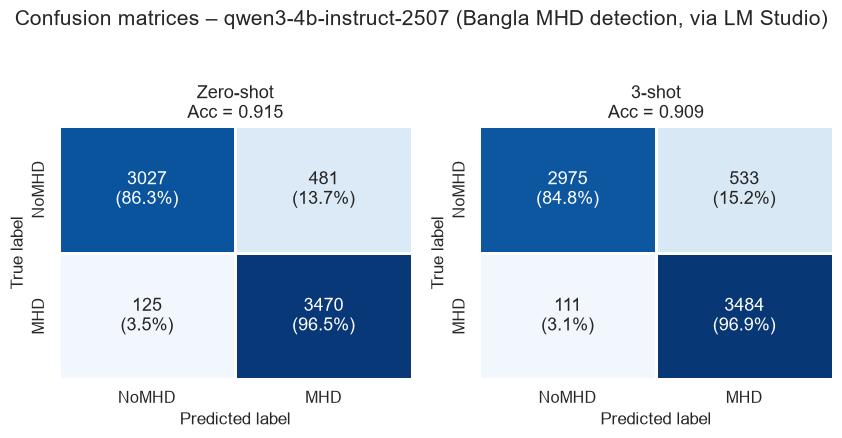

C:\Users\pc\AppData\Local\Temp\ipykernel_2656\2127055190.py:34: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(data=m, x="Setting", y="Score", hue="Metric", palette=PAL, ax=ax)


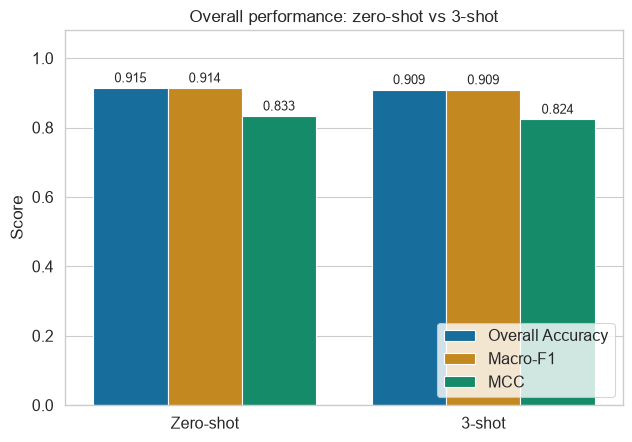

C:\Users\pc\AppData\Local\Temp\ipykernel_2656\2127055190.py:49: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(data=t, x="Setting", y="Score", hue="Metric", palette=PAL, ax=ax)
C:\Users\pc\AppData\Local\Temp\ipykernel_2656\2127055190.py:49: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(data=t, x="Setting", y="Score", hue="Metric", palette=PAL, ax=ax)


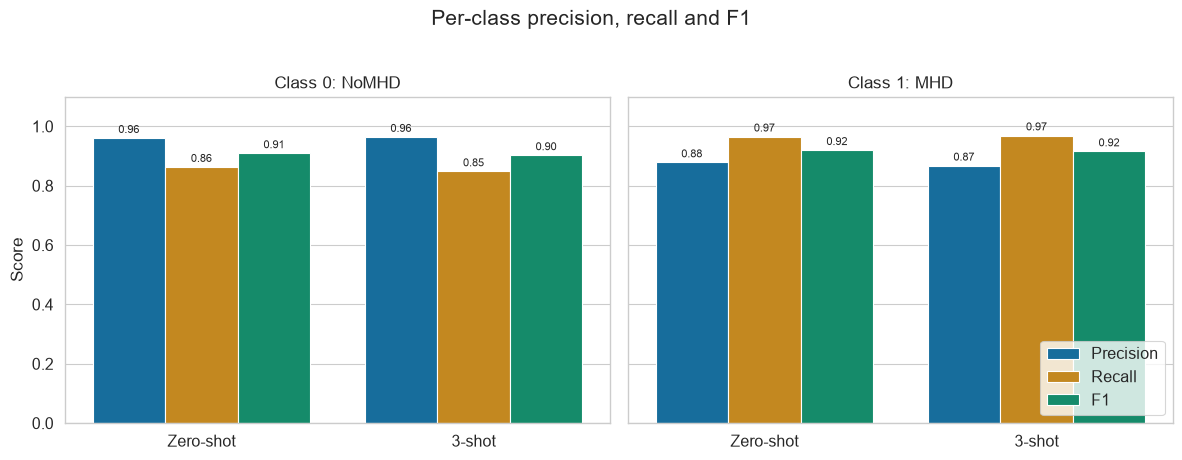

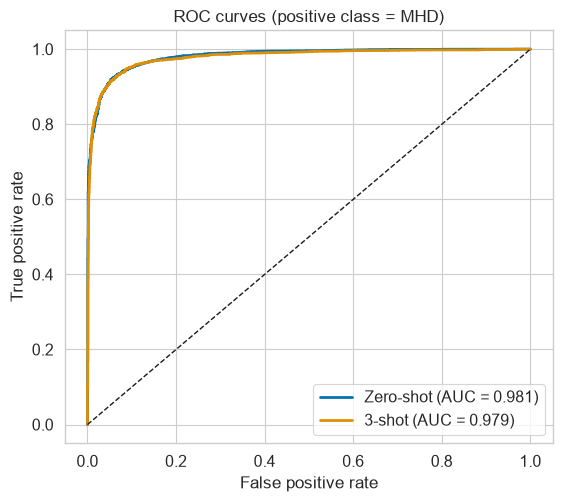

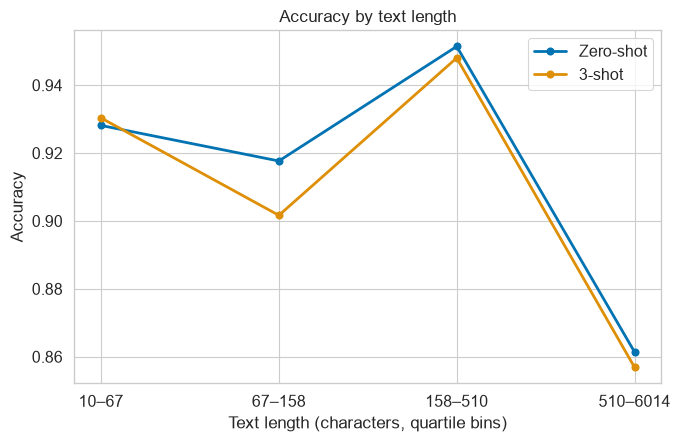

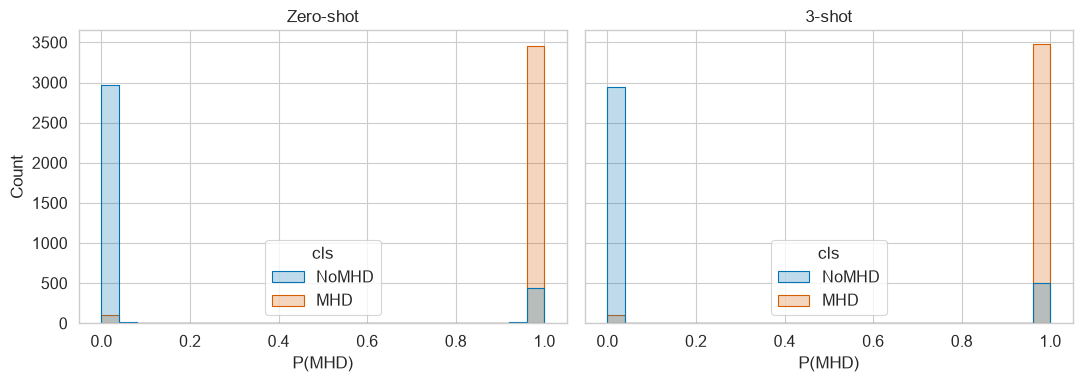

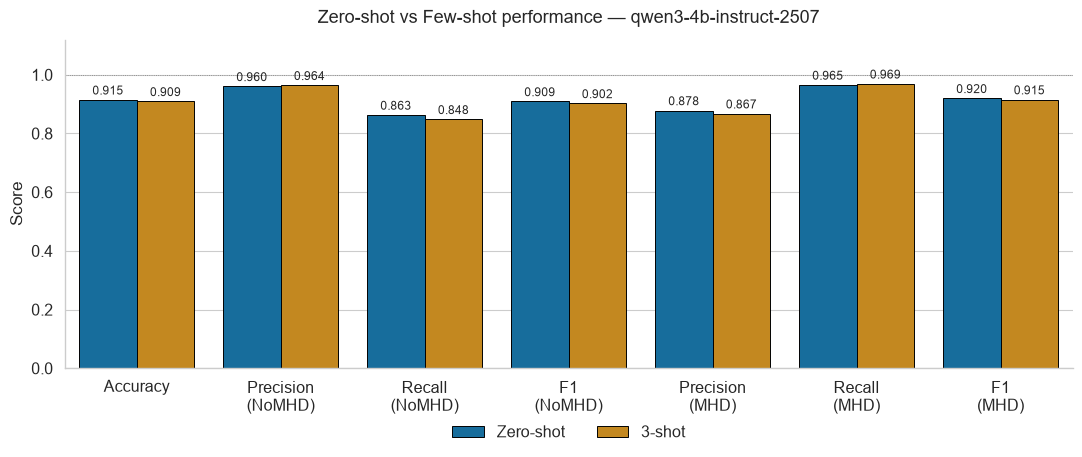

In [20]:
def save_fig(fig, name):
    fig.savefig(f"{OUT_DIR}/{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"{OUT_DIR}/{name}.pdf", bbox_inches="tight")

names  = list(preds.keys())
labels = [CLASS_NAMES[0], CLASS_NAMES[1]]

# ---- Fig 1: Confusion matrices ----
def draw_cm(ax, y, yp, title):
    cm = confusion_matrix(y, yp, labels=[0, 1])
    pct = cm / cm.sum(axis=1, keepdims=True) * 100
    annot = np.array([[f"{cm[i,j]}\n({pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)])
    sns.heatmap(pct, annot=annot, fmt="", cmap="Blues", vmin=0, vmax=100, cbar=False,
                xticklabels=labels, yticklabels=labels, linewidths=1, linecolor="white",
                annot_kws={"size": 13}, ax=ax)
    ax.set_title(f"{title}\nAcc = {(yp==y).mean():.3f}", fontsize=13)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")

fig, axes = plt.subplots(1, len(names), figsize=(4.3*len(names), 4.2))
axes = np.atleast_1d(axes)
for ax, n in zip(axes, names):
    draw_cm(ax, preds[n].label.values, preds[n].pred.values, n)
fig.suptitle(f"Confusion matrices – {MODEL_NAME} (Bangla MHD detection, via LM Studio)", y=1.04, fontsize=15)
plt.tight_layout(); save_fig(fig, "fig1_confusion_matrices"); plt.show()

for n in names:
    f, a = plt.subplots(figsize=(4.5, 4.2))
    draw_cm(a, preds[n].label.values, preds[n].pred.values, n)
    plt.tight_layout(); save_fig(f, f"cm_{n.replace(' ', '_')}"); plt.close(f)

# ---- Fig 2: Overall accuracy / macro-F1 / MCC ----
fig, ax = plt.subplots(figsize=(6.5, 4.6))
m = metrics[["Overall Accuracy", "Macro-F1", "MCC"]].reset_index().melt("Setting", var_name="Metric", value_name="Score")
sns.barplot(data=m, x="Setting", y="Score", hue="Metric", palette=PAL, ax=ax)
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=9, padding=2)
ax.set_ylim(0, 1.08); ax.set_xlabel(""); ax.set_ylabel("Score")
ax.set_title("Overall performance: zero-shot vs 3-shot")
ax.legend(loc="lower right", frameon=True)
plt.tight_layout(); save_fig(fig, "fig2_overall_performance"); plt.show()

# ---- Fig 3: Per-class precision / recall / F1 ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, c in zip(axes, [0, 1]):
    cn = CLASS_NAMES[c]
    t = metrics[[f"Precision ({cn})", f"Recall ({cn})", f"F1 ({cn})"]].copy()
    t.columns = ["Precision", "Recall", "F1"]
    t = t.reset_index().melt("Setting", var_name="Metric", value_name="Score")
    sns.barplot(data=t, x="Setting", y="Score", hue="Metric", palette=PAL, ax=ax)
    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.2f", fontsize=8, padding=2)
    ax.set_title(f"Class {c}: {cn}"); ax.set_xlabel(""); ax.set_ylim(0, 1.1)
    if c == 1: ax.legend(loc="lower right", frameon=True)
    else: ax.legend().remove()
plt.suptitle("Per-class precision, recall and F1", y=1.02, fontsize=15)
plt.tight_layout(); save_fig(fig, "fig3_per_class_metrics"); plt.show()

# ---- Fig 4: ROC curves ----
fig, ax = plt.subplots(figsize=(5.8, 5.2))
for col, n in zip(PAL, names):
    fpr, tpr, _ = roc_curve(preds[n].label, preds[n].p_mhd)
    ax.plot(fpr, tpr, lw=2, color=col, label=f"{n} (AUC = {roc_auc_score(preds[n].label, preds[n].p_mhd):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curves (positive class = MHD)"); ax.legend(loc="lower right")
plt.tight_layout(); save_fig(fig, "fig4_roc_curves"); plt.show()

# ---- Fig 5: Accuracy by text length ----
fig, ax = plt.subplots(figsize=(7, 4.6))
bins = pd.qcut(test_df["n_chars"], 4, duplicates="drop")
for col, n in zip(PAL, names):
    d = preds[n].assign(bin=bins.values, ok=(preds[n].label == preds[n].pred).astype(float))
    acc = d.groupby("bin", observed=True)["ok"].mean()
    ax.plot(range(len(acc)), acc.values, marker="o", lw=2, color=col, label=n)
ax.set_xticks(range(len(acc)))
ax.set_xticklabels([f"{int(i.left)}–{int(i.right)}" for i in acc.index])
ax.set_xlabel("Text length (characters, quartile bins)"); ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by text length"); ax.legend()
plt.tight_layout(); save_fig(fig, "fig5_accuracy_by_length"); plt.show()

# ---- Fig 6: P(MHD) distribution per true class ----
fig, axes = plt.subplots(1, len(names), figsize=(5.5*len(names), 4), sharey=True)
axes = np.atleast_1d(axes)
for ax, n in zip(axes, names):
    d = preds[n].assign(cls=preds[n].label.map(CLASS_NAMES))
    sns.histplot(data=d, x="p_mhd", hue="cls", bins=25, palette=[PAL[0], PAL[3]], element="step", ax=ax)
    ax.set_title(n); ax.set_xlabel("P(MHD)")
plt.tight_layout(); save_fig(fig, "fig6_probability_distribution"); plt.show()

# ---- Fig 7: Publication-style grouped bar chart across all metrics ----
metric_cols = {
    "Accuracy":            "Overall Accuracy",
    "Precision\n(NoMHD)":  "Precision (NoMHD)",
    "Recall\n(NoMHD)":     "Recall (NoMHD)",
    "F1\n(NoMHD)":         "F1 (NoMHD)",
    "Precision\n(MHD)":    "Precision (MHD)",
    "Recall\n(MHD)":       "Recall (MHD)",
    "F1\n(MHD)":           "F1 (MHD)",
}
plot_df = (metrics[list(metric_cols.values())]
          .rename(columns={v: k for k, v in metric_cols.items()})
          .reset_index().melt("Setting", var_name="Metric", value_name="Score"))

fig, ax = plt.subplots(figsize=(11, 4.8))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Setting",
            palette=PAL[:len(metrics)], edgecolor="black", linewidth=0.7, ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8.5, padding=2)
ax.set_ylim(0, 1.12); ax.set_ylabel("Score", fontsize=12); ax.set_xlabel("")
ax.set_title(f"Zero-shot vs Few-shot performance — {MODEL_NAME}", fontsize=13, pad=12)
ax.axhline(1.0, color="gray", lw=0.6, ls=":")
ax.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=len(metrics), frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); save_fig(fig, "fig7_metrics_comparison_bar"); plt.show()

Best setting: Zero-shot | errors: 606
error_type
False Positive (NoMHD→MHD)    481
False Negative (MHD→NoMHD)    125
Name: count, dtype: int64
                      error_type         p_mhd                                               text
671   False Negative (MHD→NoMHD)  6.282984e-11            আজকের আকাশ দেখতে অনেক সুন্দর লাগছে ।। 🥰
3949  False Negative (MHD→NoMHD)  2.742463e-10  তাই আমি রেনেসাঁর সময়কার ফ্রেঞ্চ টোস্ট অর্ডার ...
5841  False Negative (MHD→NoMHD)  4.384559e-10                       সম্মান ছাড়া সাফল্য অর্থহীন।
1892  False Negative (MHD→NoMHD)  5.449069e-10  আমি এমন একটি রেস্তোরাঁয় গিয়েছিলাম যেখানে যেক...
2922  False Negative (MHD→NoMHD)  6.588270e-10  এই মুহুর্তের জন্য আনন্দিত হন। এই মুহুর্তটি আপন...
5944  False Positive (NoMHD→MHD)  5.278937e-01  সোনার চামচ মুখে নিয়ে না জন্মালেও আর জীবনটা অন...
4916  False Positive (NoMHD→MHD)  5.554710e-01  ভগবানের আশীর্বাদে প্রাইমারিতে জব হয়েছে... সফল...
471   False Positive (NoMHD→MHD)  5.680433e-01  অন্য ভালোবাসা ❤ ❤️ যেদিন 

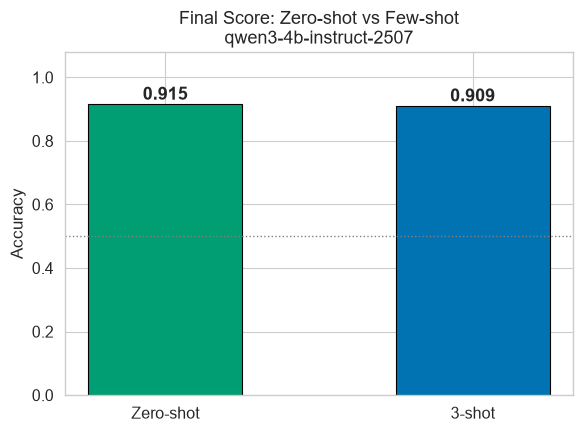


All outputs saved in: C:\Users\pc\Desktop\shuvo_vai\llm_eval_outputs_lmstudio
Zipped to: C:\Users\pc\Desktop\shuvo_vai\llm_eval_outputs_lmstudio.zip


In [21]:
# ---- Error analysis ----
best = metrics["Overall Accuracy"].idxmax()
err = preds[best].copy()
err["error_type"] = np.where((err.label == 0) & (err.pred == 1), "False Positive (NoMHD→MHD)",
                     np.where((err.label == 1) & (err.pred == 0), "False Negative (MHD→NoMHD)", "Correct"))
err = err[err.error_type != "Correct"].sort_values("p_mhd")
err.to_csv(f"{OUT_DIR}/errors_{best.replace(' ', '_')}.csv", index=False)
print(f"Best setting: {best} | errors: {len(err)}")
print(err.error_type.value_counts())
print(err.groupby("error_type").head(5)[["error_type", "p_mhd", "text"]])

# ---- Live score summary: final scoreboard for Zero-shot vs Few-shot ----
acc_col = "Overall Accuracy" if "Overall Accuracy" in metrics.columns else "Accuracy"
print("\n" + "=" * 60)
print("  LIVE SCORE SUMMARY")
print("=" * 60)
scoreboard = metrics[[acc_col]].round(4)
for name, row in scoreboard.iterrows():
    bar = "█" * int(row[acc_col] * 40)
    print(f"  {name:<10} | Accuracy: {row[acc_col]:.4f} {bar}")
print("=" * 60)
winner = scoreboard[acc_col].idxmax()
diff = scoreboard[acc_col].max() - scoreboard[acc_col].min()
print(f"  Best setting: {winner}  (+{diff:.4f} over the other)")
print("=" * 60)

fig, ax = plt.subplots(figsize=(6, 4.5))
colors = [PAL[2] if n == winner else PAL[0] for n in scoreboard.index]
bars = ax.bar(scoreboard.index, scoreboard[acc_col], color=colors, width=0.5, edgecolor="black", linewidth=0.8)
for bar, (name, row) in zip(bars, scoreboard.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, row[acc_col] + 0.015, f"{row[acc_col]:.3f}",
            ha="center", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.08); ax.set_ylabel("Accuracy")
ax.set_title(f"Final Score: Zero-shot vs Few-shot\n{MODEL_NAME}", fontsize=13)
ax.axhline(0.5, ls=":", color="gray", lw=1)
plt.tight_layout(); save_fig(fig, "fig8_live_score_summary"); plt.show()

# ---- Zip everything ----
zip_path = shutil.make_archive("llm_eval_outputs_lmstudio", "zip", OUT_DIR)
print("\nAll outputs saved in:", os.path.abspath(OUT_DIR))
print("Zipped to:", os.path.abspath(zip_path))


  LIVE SCORE SUMMARY
  Zero-shot  | Accuracy: 0.9147 ████████████████████████████████████
  3-shot     | Accuracy: 0.9093 ████████████████████████████████████
  Best setting: Zero-shot  (+0.0054 over the other)


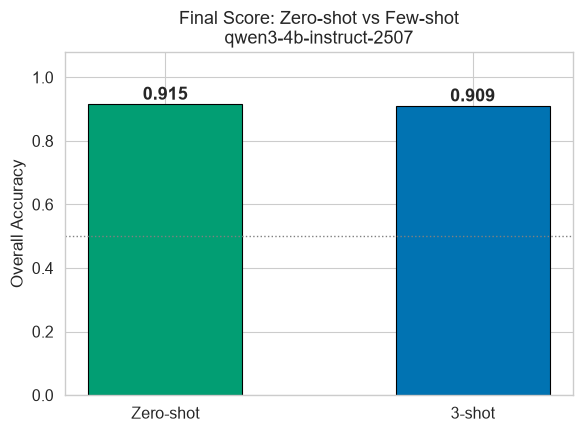

In [22]:
# ---- Live score summary: final scoreboard for Zero-shot vs Few-shot ----
print("\n" + "=" * 60)
print("  LIVE SCORE SUMMARY")
print("=" * 60)
scoreboard = metrics[["Overall Accuracy", "Macro-F1"]].round(4)
for name, row in scoreboard.iterrows():
    bar = "█" * int(row["Overall Accuracy"] * 40)
    print(f"  {name:<10} | Accuracy: {row['Overall Accuracy']:.4f} {bar}")
print("=" * 60)
winner = scoreboard["Overall Accuracy"].idxmax()
diff = scoreboard["Overall Accuracy"].max() - scoreboard["Overall Accuracy"].min()
print(f"  Best setting: {winner}  (+{diff:.4f} over the other)")
print("=" * 60)

# ---- Fig 7: Live score scoreboard figure ----
fig, ax = plt.subplots(figsize=(6, 4.5))
colors = [PAL[2] if n == winner else PAL[0] for n in scoreboard.index]
bars = ax.bar(scoreboard.index, scoreboard["Overall Accuracy"], color=colors, width=0.5, edgecolor="black", linewidth=0.8)
for bar, (name, row) in zip(bars, scoreboard.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, row["Overall Accuracy"] + 0.015,
            f"{row['Overall Accuracy']:.3f}", ha="center", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.08)
ax.set_ylabel("Overall Accuracy")
ax.set_title(f"Final Score: Zero-shot vs Few-shot\n{MODEL_NAME}", fontsize=13)
ax.axhline(0.5, ls=":", color="gray", lw=1)
plt.tight_layout()
save_fig(fig, "fig7_live_score_summary")
plt.show()